# 유입수질(`_in`) ↔ TMS(`_VU`) 상관 분석

**데이터**
- `data/actual/TMS_extended.csv` : `_VU` 6개 변수 (TOC/PH/SS/FLUX/TN/TP)
- `data/actual/FLOW_extended.csv` : `_in` 8개 변수 (BOD/COD/PH/SS/TN/TOC/TP/WATER_TEMP)
- 겹치는 기간 : 2025-11-22 ~ 2026-02-23 → 30분 리샘플 후 inner join

**저장 경로** : `results/correlation/`

| 파일 | 내용 |
|---|---|
| `in_vu_heatmap.png` | Pearson / Spearman 상관계수 히트맵 (나란히) |
| `in_vu_lag_crosscorr.png` | 시간 지연(lag) 교차상관 — _VU별 최적 지연 탐색 |
| `in_vu_lag_heatmap.png` | 최적 lag 적용 후 재계산한 상관계수 히트맵 |
| `in_vu_scatter_pairs.png` | 의미 있는 동종 쌍 산점도 + 회귀선 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

BASE = Path('../../')
OUT  = BASE / 'results' / 'correlation'
OUT.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUT.resolve())

Output dir: C:\project_WWTP\python\results\correlation


## 1. 데이터 로드 및 머지 (30분 리샘플, inner join)

In [2]:
tms = pd.read_csv(BASE / 'data/actual/TMS_extended.csv', parse_dates=['SYS_TIME'])
tms.sort_values('SYS_TIME', inplace=True)
tms.set_index('SYS_TIME', inplace=True)

flow = pd.read_csv(BASE / 'data/actual/FLOW_extended.csv', parse_dates=['SYS_TIME'])
flow.sort_values('SYS_TIME', inplace=True)
flow.set_index('SYS_TIME', inplace=True)

# 30분 리샘플
tms_30  = tms.resample('30min').mean()
flow_30 = flow.resample('30min').mean()

# inner join — 겹치는 기간만
merged = tms_30.join(flow_30, how='inner')

VU_COLS = [c for c in merged.columns if c.endswith('_VU')]
IN_COLS = [c for c in merged.columns if c.endswith('_in')]

print(f'Merged  : {merged.shape}  ({merged.index[0]} ~ {merged.index[-1]})')
print(f'_VU ({len(VU_COLS)}): {VU_COLS}')
print(f'_in ({len(IN_COLS)}): {IN_COLS}')

df = merged[VU_COLS + IN_COLS].dropna()
print(f'\n분석 행 수 (dropna): {len(df):,}')

Merged  : (4445, 21)  (2025-11-22 23:30:00 ~ 2026-02-23 13:30:00)
_VU (6): ['TOC_VU', 'PH_VU', 'SS_VU', 'FLUX_VU', 'TN_VU', 'TP_VU']
_in (8): ['BOD_in', 'COD_in', 'PH_in', 'SS_in', 'TN_in', 'TOC_in', 'TP_in', 'WATER_TEMP_in']

분석 행 수 (dropna): 3,984


## 2. 상관계수 히트맵 — Pearson & Spearman

In [3]:
def cross_corr_matrix(df, row_cols, col_cols, method='pearson'):
    mat  = pd.DataFrame(index=row_cols, columns=col_cols, dtype=float)
    pval = pd.DataFrame(index=row_cols, columns=col_cols, dtype=float)
    for r in row_cols:
        for c in col_cols:
            x, y = df[r].values, df[c].values
            if method == 'pearson':
                corr, p = stats.pearsonr(x, y)
            else:
                corr, p = stats.spearmanr(x, y)
            mat.loc[r, c]  = corr
            pval.loc[r, c] = p
    return mat.astype(float), pval.astype(float)

pearson_mat,  pearson_p  = cross_corr_matrix(df, VU_COLS, IN_COLS, 'pearson')
spearman_mat, spearman_p = cross_corr_matrix(df, VU_COLS, IN_COLS, 'spearman')

print('Pearson r matrix:')
display(pearson_mat.round(3))

Pearson r matrix:


,BOD_in,COD_in,PH_in,SS_in,TN_in,TOC_in,TP_in,WATER_TEMP_in
TOC_VU,0.022,0.006,0.010,0.005,0.002,-0.002,0.011,-0.049
PH_VU,-0.057,-0.025,0.028,0.065,-0.066,0.017,0.035,0.404
SS_VU,-0.058,-0.007,-0.225,-0.101,-0.003,-0.059,-0.064,-0.193
FLUX_VU,0.039,-0.030,0.064,-0.031,0.003,-0.028,-0.033,0.024
TN_VU,0.093,0.083,0.018,0.074,0.052,0.033,0.090,-0.269
TP_VU,0.092,0.096,-0.018,0.060,0.092,-0.093,0.099,-0.192


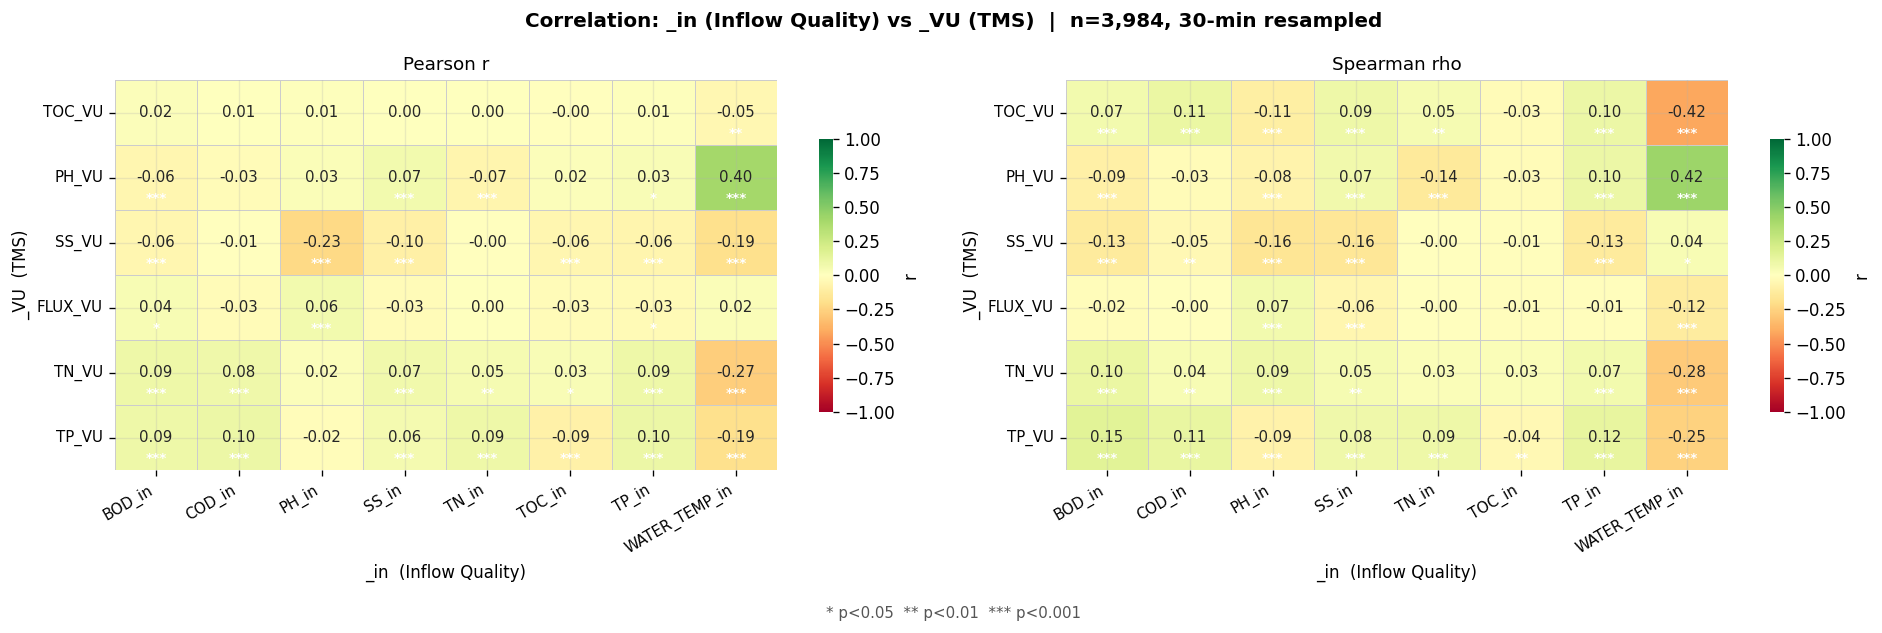

Saved: in_vu_heatmap.png


In [4]:
def sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def annotate_sig(ax, pval_df, fontsize=8):
    for i, row in enumerate(pval_df.index):
        for j, col in enumerate(pval_df.columns):
            marker = sig_marker(pval_df.loc[row, col])
            if marker:
                ax.text(j + 0.5, i + 0.82, marker, ha='center', va='center',
                        fontsize=fontsize, color='white', fontweight='bold')

n_samples = len(df)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    f'Correlation: _in (Inflow Quality) vs _VU (TMS)'
    f'  |  n={n_samples:,}, 30-min resampled',
    fontsize=12, fontweight='bold'
)

heatmap_kw = dict(
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='#cccccc',
    cbar_kws={'shrink': 0.7, 'label': 'r'},
)

titles = ['Pearson r', 'Spearman rho']
mats   = [pearson_mat, spearman_mat]
pvals  = [pearson_p,   spearman_p]

for ax, mat, pval, title in zip(axes, mats, pvals, titles):
    sns.heatmap(mat, ax=ax, **heatmap_kw)
    annotate_sig(ax, pval)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xlabel('_in  (Inflow Quality)', fontsize=10)
    ax.set_ylabel('_VU  (TMS)', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

fig.text(0.5, -0.03,
         '* p<0.05  ** p<0.01  *** p<0.001',
         ha='center', fontsize=9, color='#555')
plt.tight_layout()
fig.savefig(OUT / 'in_vu_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: in_vu_heatmap.png')

## 3. 시간 지연(Lag) 교차상관

유입수질(`_in`)은 처리 공정을 거쳐 TMS(`_VU`)에 영향을 주므로, **lag -24 ~ +48 스텝(-12h ~ +24h)** 구간에서 최대 상관이 나타나는 지연을 탐색합니다.

In [5]:
MAX_LAG_NEG = 24
MAX_LAG_POS = 48
LAGS = np.arange(-MAX_LAG_NEG, MAX_LAG_POS + 1)
lag_hours = LAGS * 0.5

# VU별로 가장 높은 Pearson |r| 파트너 찾기 (lag=0)
best_pairs = {vu: pearson_mat.loc[vu].abs().idxmax() for vu in VU_COLS}
print('최고 상관 파트너 (Pearson abs, lag=0):')
for vu, in_col in best_pairs.items():
    print(f'  {vu:10s} <-> {in_col:18s}  r={pearson_mat.loc[vu, in_col]:.3f}')

최고 상관 파트너 (Pearson abs, lag=0):
  TOC_VU     <-> WATER_TEMP_in       r=-0.049
  PH_VU      <-> WATER_TEMP_in       r=0.404
  SS_VU      <-> PH_in               r=-0.225
  FLUX_VU    <-> PH_in               r=0.064
  TN_VU      <-> WATER_TEMP_in       r=-0.269
  TP_VU      <-> WATER_TEMP_in       r=-0.192


In [6]:
def lag_corr_series(x_series, y_series, lags):
    """lag별 Pearson r. lag>0 -> x가 y보다 lag만큼 앞서는 경우 (_in 선행)."""
    x = x_series.values
    y = y_series.values
    rs = []
    for lag in lags:
        if lag > 0:
            xi, yi = x[:-lag], y[lag:]
        elif lag < 0:
            xi, yi = x[-lag:], y[:lag]
        else:
            xi, yi = x, y
        mask = ~(np.isnan(xi) | np.isnan(yi))
        if mask.sum() > 30:
            rs.append(stats.pearsonr(xi[mask], yi[mask])[0])
        else:
            rs.append(np.nan)
    return np.array(rs)

# 전체 VU x IN 조합 계산
LAG_RESULTS = {}
for vu in VU_COLS:
    for in_col in IN_COLS:
        LAG_RESULTS[(vu, in_col)] = lag_corr_series(
            merged[in_col], merged[vu], LAGS
        )
print('Lag cross-correlation 계산 완료')

Lag cross-correlation 계산 완료


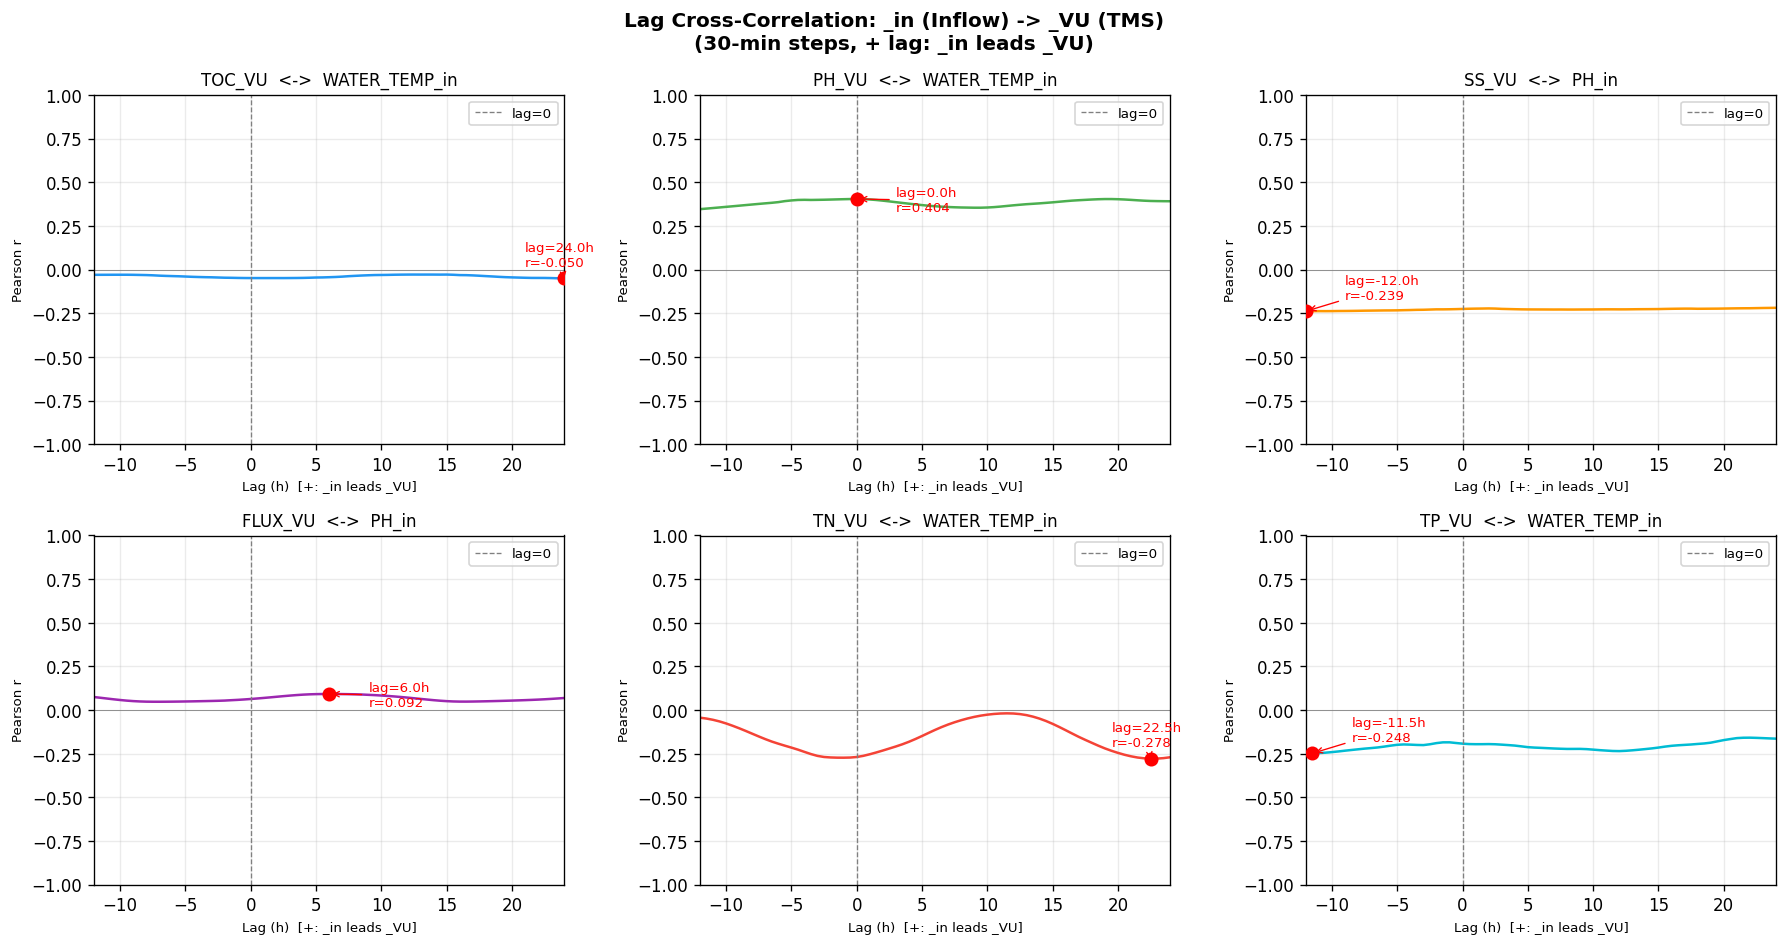

Saved: in_vu_lag_crosscorr.png


In [7]:
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, vu in enumerate(VU_COLS):
    ax   = axes[i]
    best_in = best_pairs[vu]
    rs   = LAG_RESULTS[(vu, best_in)]

    ax.plot(lag_hours, rs, color=COLORS[i], lw=1.5)
    ax.axvline(0,  color='gray', lw=0.8, linestyle='--', label='lag=0')
    ax.axhline(0,  color='gray', lw=0.5)

    best_idx  = np.nanargmax(np.abs(rs))
    best_lag_h = lag_hours[best_idx]
    best_r    = rs[best_idx]
    ax.scatter([best_lag_h], [best_r], color='red', zorder=5, s=55)
    offset_x = 3 if best_lag_h < 10 else -3
    ax.annotate(
        f'lag={best_lag_h:.1f}h\nr={best_r:.3f}',
        xy=(best_lag_h, best_r),
        xytext=(best_lag_h + offset_x, best_r - 0.07 * np.sign(best_r)),
        fontsize=8, color='red',
        arrowprops=dict(arrowstyle='->', color='red', lw=0.8)
    )

    ax.set_title(f'{vu}  <->  {best_in}', fontsize=10)
    ax.set_xlabel('Lag (h)  [+: _in leads _VU]', fontsize=8)
    ax.set_ylabel('Pearson r', fontsize=8)
    ax.set_xlim(lag_hours[0], lag_hours[-1])
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=8)

fig.suptitle(
    'Lag Cross-Correlation: _in (Inflow) -> _VU (TMS)\n'
    '(30-min steps, + lag: _in leads _VU)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT / 'in_vu_lag_crosscorr.png', bbox_inches='tight')
plt.show()
print('Saved: in_vu_lag_crosscorr.png')

## 4. 최적 Lag에서의 상관 히트맵

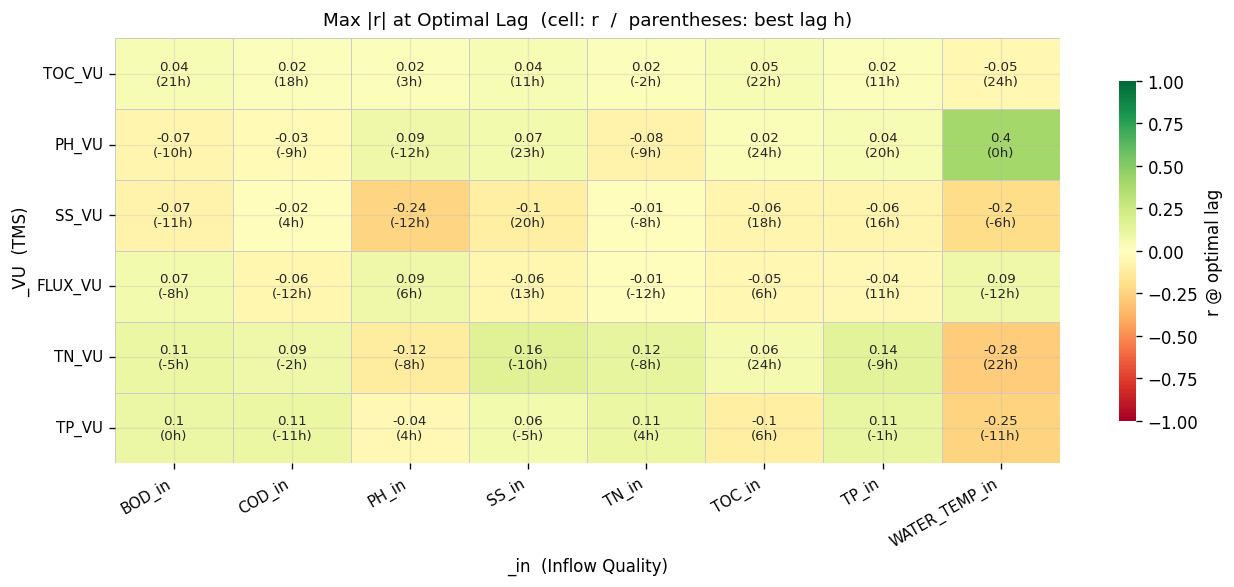

Saved: in_vu_lag_heatmap.png


In [8]:
opt_r   = pd.DataFrame(index=VU_COLS, columns=IN_COLS, dtype=float)
opt_lag = pd.DataFrame(index=VU_COLS, columns=IN_COLS, dtype=float)

for vu in VU_COLS:
    for in_col in IN_COLS:
        rs = LAG_RESULTS[(vu, in_col)]
        best_idx = np.nanargmax(np.abs(rs))
        opt_r.loc[vu, in_col]   = rs[best_idx]
        opt_lag.loc[vu, in_col] = lag_hours[best_idx]

# 셀에 r값 + 최적 lag 함께 표시
annot_text = (
    opt_r.round(2).astype(str) + '\n'
    + '(' + opt_lag.astype(int).astype(str) + 'h)'
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    opt_r.astype(float),
    ax=ax,
    annot=annot_text,
    fmt='',
    annot_kws={'size': 8},
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='#cccccc',
    cbar_kws={'shrink': 0.8, 'label': 'r @ optimal lag'}
)
ax.set_title(
    'Max |r| at Optimal Lag  (cell: r  /  parentheses: best lag h)',
    fontsize=11, pad=8
)
ax.set_xlabel('_in  (Inflow Quality)', fontsize=10)
ax.set_ylabel('_VU  (TMS)', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
fig.savefig(OUT / 'in_vu_lag_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: in_vu_lag_heatmap.png')

## 5. 산점도 — 의미 있는 동종 쌍

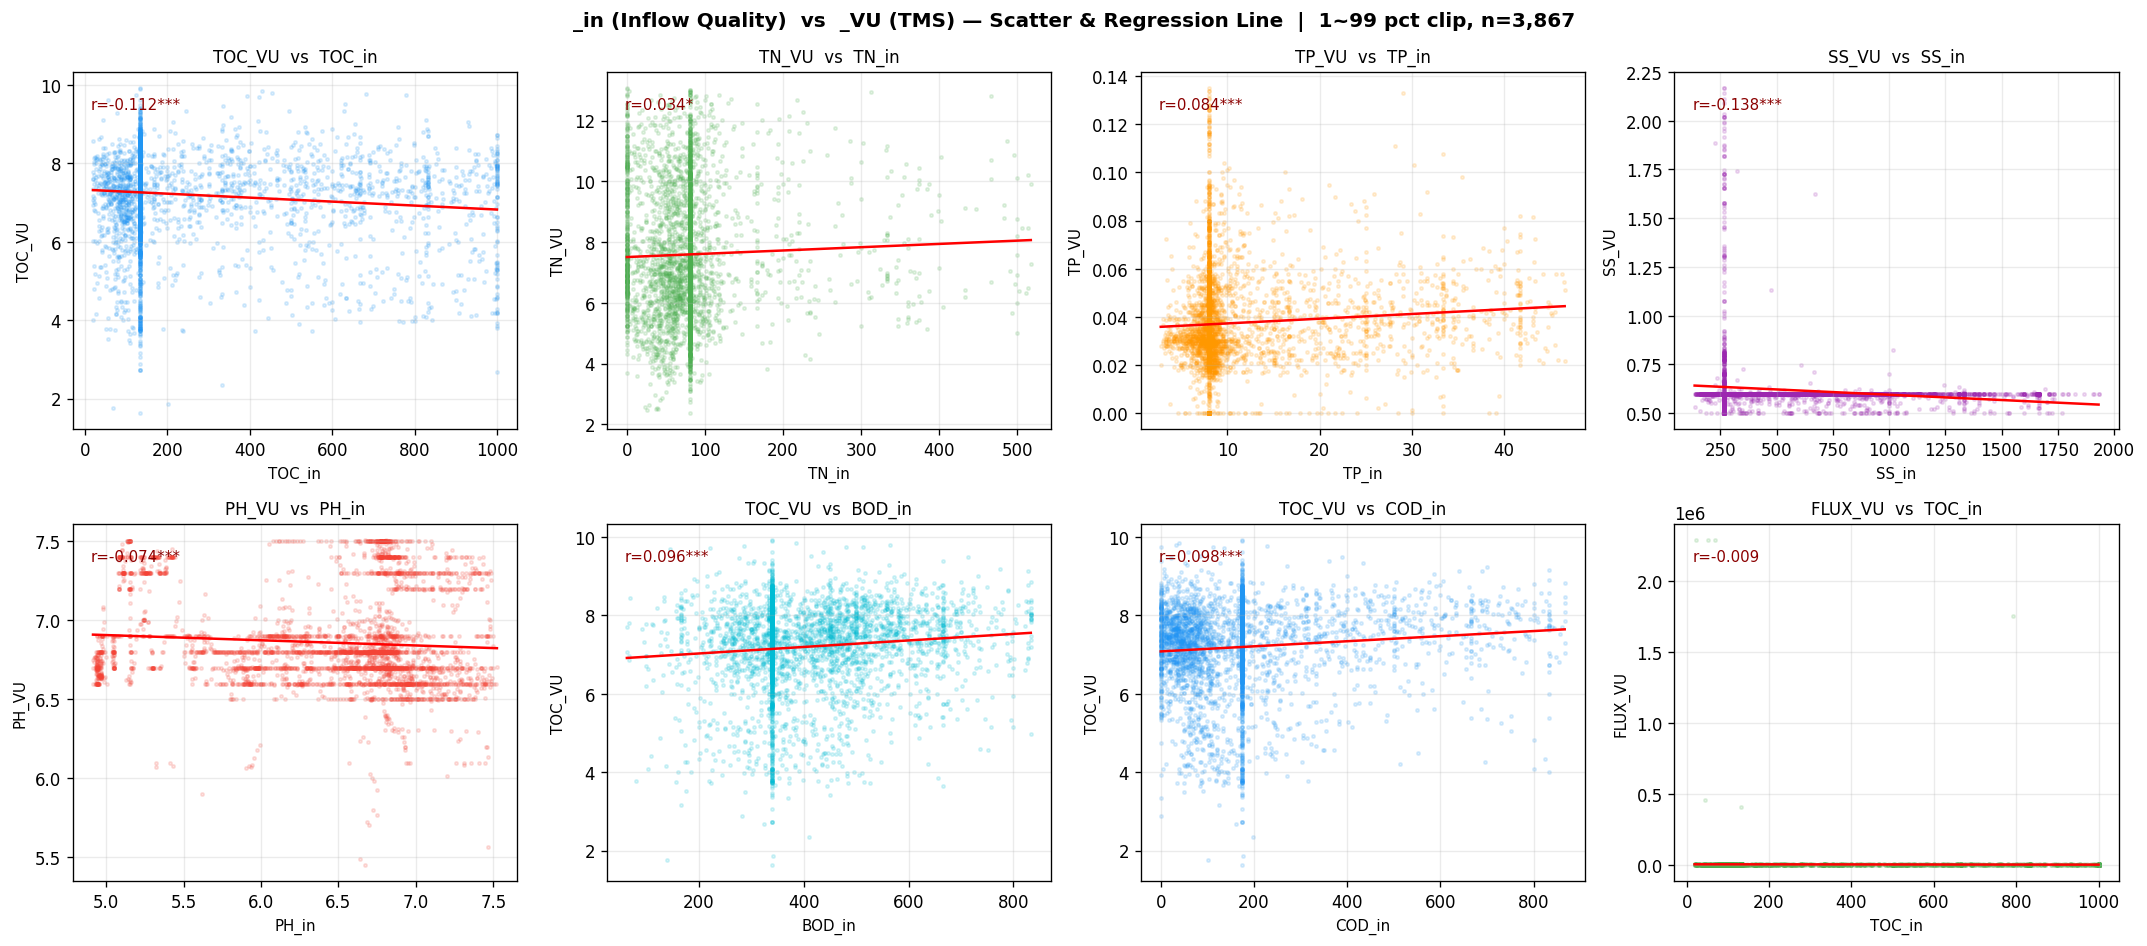

Saved: in_vu_scatter_pairs.png


In [9]:
SEMANTIC_PAIRS = [
    ('TOC_VU', 'TOC_in'),
    ('TN_VU',  'TN_in'),
    ('TP_VU',  'TP_in'),
    ('SS_VU',  'SS_in'),
    ('PH_VU',  'PH_in'),
    ('TOC_VU', 'BOD_in'),
    ('TOC_VU', 'COD_in'),
    ('FLUX_VU','TOC_in'),
]

ncols = 4
nrows = int(np.ceil(len(SEMANTIC_PAIRS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4))
axes = axes.flatten()

for i, (vu, in_col) in enumerate(SEMANTIC_PAIRS):
    ax = axes[i]
    x  = df[in_col].values
    y  = df[vu].values

    # 1~99 백분위 클리핑
    xq = np.percentile(x, [1, 99])
    yq = np.percentile(y, [1, 99])
    mask = (x >= xq[0]) & (x <= xq[1]) & (y >= yq[0]) & (y <= yq[1])
    xm, ym = x[mask], y[mask]

    ax.scatter(xm, ym, alpha=0.15, s=4, color=COLORS[i % len(COLORS)])

    slope, intercept, r, p, _ = stats.linregress(xm, ym)
    x_line = np.linspace(xm.min(), xm.max(), 200)
    ax.plot(x_line, slope * x_line + intercept, 'r-', lw=1.5)

    sig = sig_marker(p)
    ax.set_title(f'{vu}  vs  {in_col}', fontsize=10)
    ax.set_xlabel(in_col, fontsize=9)
    ax.set_ylabel(vu, fontsize=9)
    ax.text(0.04, 0.93, f'r={r:.3f}{sig}',
            transform=ax.transAxes, fontsize=9, color='darkred', va='top')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

n_clip = mask.sum()
fig.suptitle(
    f'_in (Inflow Quality)  vs  _VU (TMS) — Scatter & Regression Line'
    f'  |  1~99 pct clip, n={n_clip:,}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(OUT / 'in_vu_scatter_pairs.png', bbox_inches='tight')
plt.show()
print('Saved: in_vu_scatter_pairs.png')

## 6. 요약

In [10]:
print('=== Pearson r (lag=0) ===')
display(pearson_mat.round(3))

print('\n=== 최적 Lag 요약 ===')
rows = []
for vu in VU_COLS:
    best_in = pearson_mat.loc[vu].abs().idxmax()
    rows.append({
        '_VU':        vu,
        'Best _in':   best_in,
        'r(lag=0)':   round(float(pearson_mat.loc[vu, best_in]), 3),
        'r(opt_lag)': round(float(opt_r.loc[vu, best_in]), 3),
        'opt_lag(h)': int(opt_lag.loc[vu, best_in]),
    })
display(pd.DataFrame(rows))

print('\n저장된 파일:')
for f in sorted(OUT.glob('in_vu_*.png')):
    print(f'  {f.name}')

=== Pearson r (lag=0) ===


,BOD_in,COD_in,PH_in,SS_in,TN_in,TOC_in,TP_in,WATER_TEMP_in
TOC_VU,0.022,0.006,0.010,0.005,0.002,-0.002,0.011,-0.049
PH_VU,-0.057,-0.025,0.028,0.065,-0.066,0.017,0.035,0.404
SS_VU,-0.058,-0.007,-0.225,-0.101,-0.003,-0.059,-0.064,-0.193
FLUX_VU,0.039,-0.030,0.064,-0.031,0.003,-0.028,-0.033,0.024
TN_VU,0.093,0.083,0.018,0.074,0.052,0.033,0.090,-0.269
TP_VU,0.092,0.096,-0.018,0.060,0.092,-0.093,0.099,-0.192



=== 최적 Lag 요약 ===


,_VU,Best _in,r(lag=0),r(opt_lag),opt_lag(h)
0,TOC_VU,WATER_TEMP_in,-0.049,-0.050,24
1,PH_VU,WATER_TEMP_in,0.404,0.404,0
2,SS_VU,PH_in,-0.225,-0.239,-12
3,FLUX_VU,PH_in,0.064,0.092,6
4,TN_VU,WATER_TEMP_in,-0.269,-0.278,22
5,TP_VU,WATER_TEMP_in,-0.192,-0.248,-11



저장된 파일:
  in_vu_heatmap.png
  in_vu_lag_crosscorr.png
  in_vu_lag_heatmap.png
  in_vu_scatter_pairs.png
